# Exploratory Data Analysis 
**Dataset:** `delivery_data.csv` — Logistics route & delivery time data

This notebook explores the dataset structure, distributions, and relationships
before modelling.


## 1. Import Libraries & Load Data

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("delivery_data.csv")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())


Shape: (144867, 24)
Columns: ['data', 'trip_creation_time', 'route_schedule_uuid', 'route_type', 'trip_uuid', 'source_center', 'source_name', 'destination_center', 'destination_name', 'od_start_time', 'od_end_time', 'start_scan_to_end_scan', 'is_cutoff', 'cutoff_factor', 'cutoff_timestamp', 'actual_distance_to_destination', 'actual_time', 'osrm_time', 'osrm_distance', 'factor', 'segment_actual_time', 'segment_osrm_time', 'segment_osrm_distance', 'segment_factor']


## 2. Dataset Overview

In [5]:
df.head(5)


,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:27:55,10.435660,14.0,11.0,11.9653,1.272727,14.0,11.0,11.9653,1.272727
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:17:55,18.936842,24.0,20.0,21.7243,1.200000,10.0,9.0,9.7590,1.111111
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:01:19.505586,27.637279,40.0,28.0,32.5395,1.428571,16.0,7.0,10.8152,2.285714
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:39:57,36.118028,62.0,40.0,45.5620,1.550000,21.0,12.0,13.0224,1.750000
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:33:55,39.386040,68.0,44.0,54.2181,1.545455,6.0,5.0,3.9153,1.200000


In [6]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 144867 entries, 0 to 144866
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   data                            144867 non-null  str    
 1   trip_creation_time              144867 non-null  str    
 2   route_schedule_uuid             144867 non-null  str    
 3   route_type                      144867 non-null  str    
 4   trip_uuid                       144867 non-null  str    
 5   source_center                   144867 non-null  str    
 6   source_name                     144574 non-null  str    
 7   destination_center              144867 non-null  str    
 8   destination_name                144606 non-null  str    
 9   od_start_time                   144867 non-null  str    
 10  od_end_time                     144867 non-null  str    
 11  start_scan_to_end_scan          144867 non-null  float64
 12  is_cutoff                  

In [7]:
print("Descriptive Statistics")
df.describe().round(2)


Descriptive Statistics


,start_scan_to_end_scan,cutoff_factor,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
count,144867.00,144867.00,144867.00,144867.00,144867.00,144867.00,144867.00,144867.00,144867.00,144867.00,144867.00
mean,961.26,232.93,234.07,416.93,213.87,284.77,2.12,36.20,18.51,22.83,2.22
std,1037.01,344.76,344.99,598.10,308.01,421.12,1.72,53.57,14.78,17.86,4.85
min,20.00,9.00,9.00,9.00,6.00,9.01,0.14,-244.00,0.00,0.00,-23.44
25%,161.00,22.00,23.36,51.00,27.00,29.91,1.60,20.00,11.00,12.07,1.35
50%,449.00,66.00,66.13,132.00,64.00,78.53,1.86,29.00,17.00,23.51,1.68
75%,1634.00,286.00,286.71,513.00,257.00,343.19,2.21,40.00,22.00,27.81,2.25
max,7898.00,1927.00,1927.45,4532.00,1686.00,2326.20,77.39,3051.00,1611.00,2191.40,574.25


## 3. Missing Values

Columns with missing values:
source_name         293
destination_name    261
dtype: int64


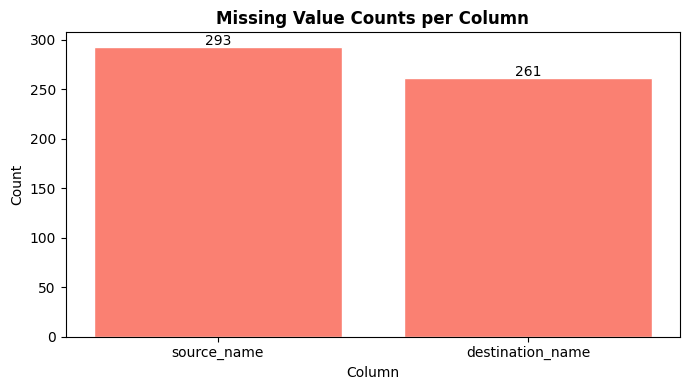

In [8]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print("Columns with missing values:")
print(missing)

if len(missing) > 0:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(missing.index, missing.values, color="salmon", edgecolor="white")
    ax.set_title("Missing Value Counts per Column", fontweight="bold")
    ax.set_ylabel("Count")
    ax.set_xlabel("Column")
    for i, v in enumerate(missing.values):
        ax.text(i, v + 2, str(v), ha="center", fontsize=10)
    plt.tight_layout()
    plt.savefig("eda_missing.png", dpi=110, bbox_inches="tight")
    plt.show()
else:
    print("No missing values found.")


## 4. Categorical Column Distributions

Train/Test split:
data
training    104858
test         40009
Name: count, dtype: int64


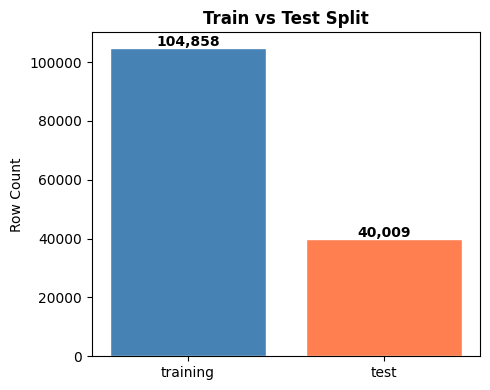

In [9]:
split_counts = df["data"].value_counts()
print("Train/Test split:")
print(split_counts)

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(split_counts.index, split_counts.values, color=["steelblue", "coral"], edgecolor="white")
ax.set_title("Train vs Test Split", fontweight="bold")
ax.set_ylabel("Row Count")
for i, v in enumerate(split_counts.values):
    ax.text(i, v + 500, f"{v:,}", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig("eda_split.png", dpi=110, bbox_inches="tight")
plt.show()


Route Type distribution:
route_type
FTL        99660
Carting    45207
Name: count, dtype: int64


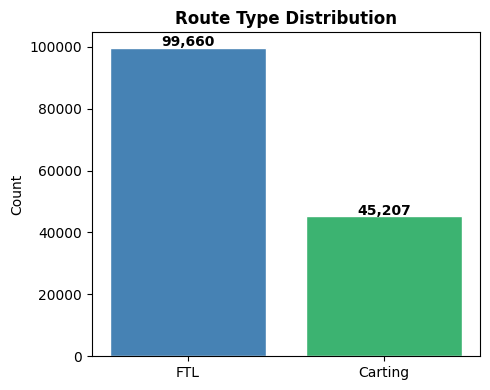

In [10]:
rt_counts = df["route_type"].value_counts()
print("Route Type distribution:")
print(rt_counts)

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(rt_counts.index, rt_counts.values, color=["steelblue", "mediumseagreen"], edgecolor="white")
ax.set_title("Route Type Distribution", fontweight="bold")
ax.set_ylabel("Count")
for i, v in enumerate(rt_counts.values):
    ax.text(i, v + 500, f"{v:,}", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig("eda_route_type.png", dpi=110, bbox_inches="tight")
plt.show()


is_cutoff distribution:
is_cutoff
True     118749
False     26118
Name: count, dtype: int64


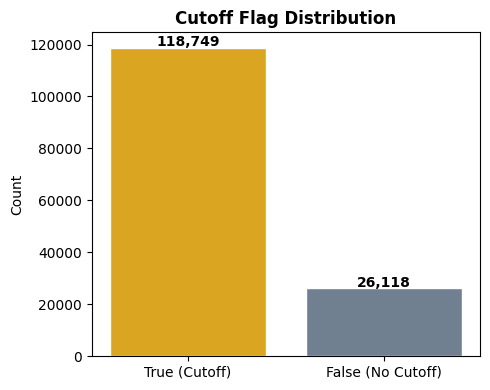

In [11]:
cutoff_counts = df["is_cutoff"].value_counts()
print("is_cutoff distribution:")
print(cutoff_counts)

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["True (Cutoff)", "False (No Cutoff)"], cutoff_counts.values,
       color=["goldenrod", "slategray"], edgecolor="white")
ax.set_title("Cutoff Flag Distribution", fontweight="bold")
ax.set_ylabel("Count")
for i, v in enumerate(cutoff_counts.values):
    ax.text(i, v + 500, f"{v:,}", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig("eda_cutoff.png", dpi=110, bbox_inches="tight")
plt.show()


## 5. Target Variable: `actual_time` (Delivery Duration, minutes)

In [12]:
print("actual_time statistics:")
print(df["actual_time"].describe().round(2))


actual_time statistics:
count    144867.00
mean        416.93
std         598.10
min           9.00
25%          51.00
50%         132.00
75%         513.00
max        4532.00
Name: actual_time, dtype: float64


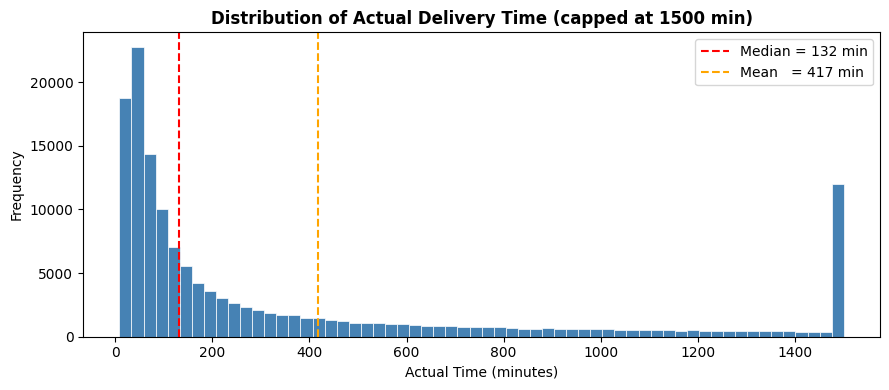

In [13]:
capped = df["actual_time"].clip(upper=1500)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(capped, bins=60, color="steelblue", edgecolor="white", linewidth=0.5)
ax.set_title("Distribution of Actual Delivery Time (capped at 1500 min)", fontweight="bold")
ax.set_xlabel("Actual Time (minutes)")
ax.set_ylabel("Frequency")
ax.axvline(df["actual_time"].median(), color="red",    linestyle="--", linewidth=1.5, label=f"Median = {df['actual_time'].median():.0f} min")
ax.axvline(df["actual_time"].mean(),   color="orange", linestyle="--", linewidth=1.5, label=f"Mean   = {df['actual_time'].mean():.0f} min")
ax.legend()
plt.tight_layout()
plt.savefig("eda_actual_time_dist.png", dpi=110, bbox_inches="tight")
plt.show()


Delivery time by route type:
             mean  median
route_type               
Carting      70.6    48.0
FTL         574.0   279.0


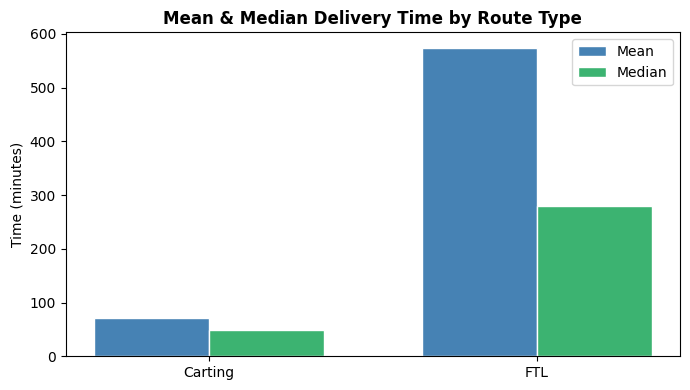

In [14]:
grouped = df.groupby("route_type")["actual_time"].agg(["mean", "median"]).round(1)
print("Delivery time by route type:")
print(grouped)

x = range(len(grouped))
w = 0.35
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([i - w/2 for i in x], grouped["mean"],   width=w, label="Mean",   color="steelblue",    edgecolor="white")
ax.bar([i + w/2 for i in x], grouped["median"], width=w, label="Median", color="mediumseagreen", edgecolor="white")
ax.set_xticks(list(x))
ax.set_xticklabels(grouped.index)
ax.set_title("Mean & Median Delivery Time by Route Type", fontweight="bold")
ax.set_ylabel("Time (minutes)")
ax.legend()
plt.tight_layout()
plt.savefig("eda_time_by_route.png", dpi=110, bbox_inches="tight")
plt.show()


## 6. Key Numeric Feature Distributions

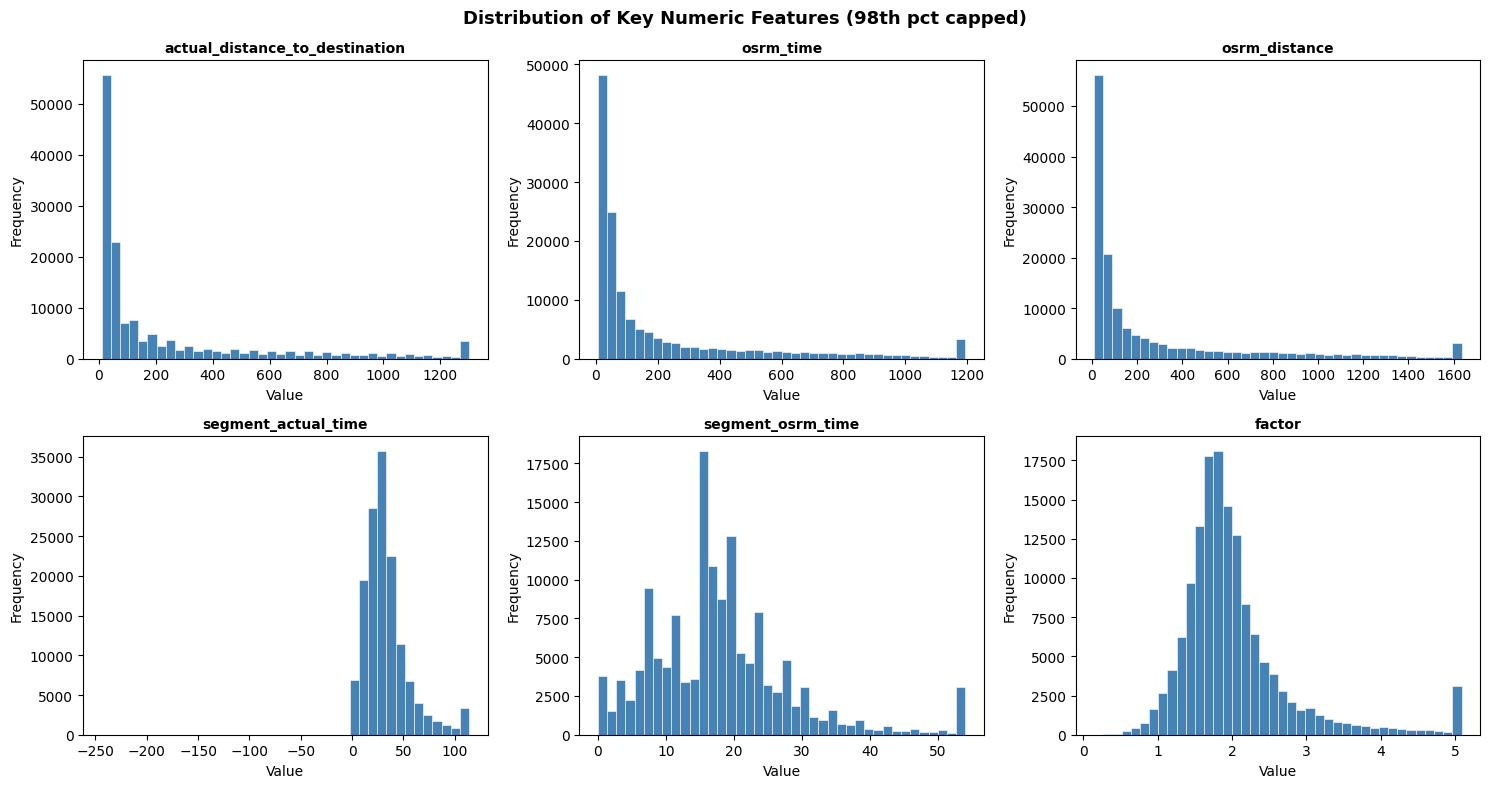

In [15]:
numeric_cols = ["actual_distance_to_destination", "osrm_time", "osrm_distance",
                "segment_actual_time", "segment_osrm_time", "factor"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    data = df[col].clip(upper=df[col].quantile(0.98))   # trim extreme outliers for visibility
    ax.hist(data, bins=40, color="steelblue", edgecolor="white", linewidth=0.4)
    ax.set_title(col, fontweight="bold", fontsize=10)
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")

plt.suptitle("Distribution of Key Numeric Features (98th pct capped)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_numeric_dists.png", dpi=110, bbox_inches="tight")
plt.show()


## 7. Relationships with Target Variable

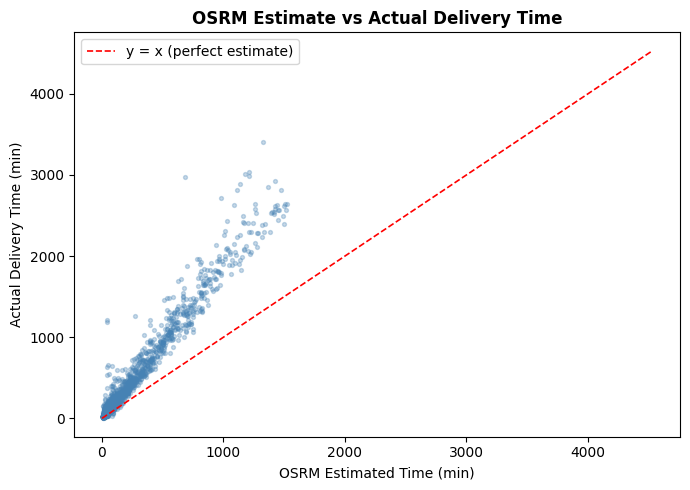

In [16]:
sample_idx = np.random.choice(len(df), 2000, replace=False)
sample = df.iloc[sample_idx]

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(sample["osrm_time"], sample["actual_time"], alpha=0.3, s=8, color="steelblue")
max_val = max(df["osrm_time"].max(), df["actual_time"].max())
ax.plot([0, max_val], [0, max_val], color="red", linestyle="--", linewidth=1.2, label="y = x (perfect estimate)")
ax.set_xlabel("OSRM Estimated Time (min)")
ax.set_ylabel("Actual Delivery Time (min)")
ax.set_title("OSRM Estimate vs Actual Delivery Time", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("eda_osrm_vs_actual.png", dpi=110, bbox_inches="tight")
plt.show()


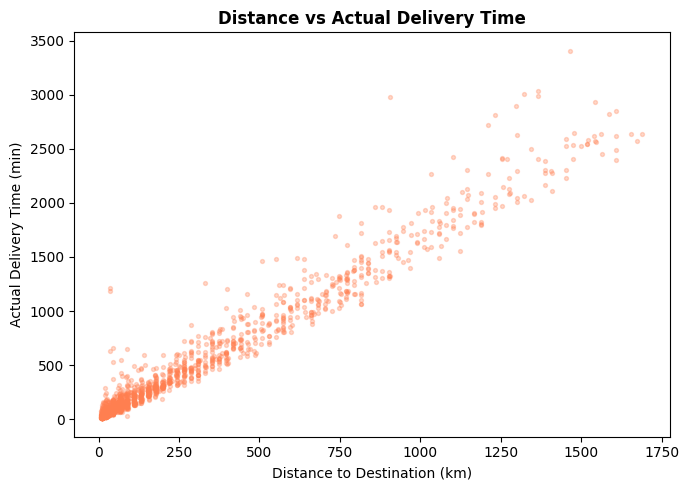

In [17]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(sample["actual_distance_to_destination"], sample["actual_time"],
           alpha=0.3, s=8, color="coral")
ax.set_xlabel("Distance to Destination (km)")
ax.set_ylabel("Actual Delivery Time (min)")
ax.set_title("Distance vs Actual Delivery Time", fontweight="bold")
plt.tight_layout()
plt.savefig("eda_distance_vs_time.png", dpi=110, bbox_inches="tight")
plt.show()


'factor' = actual_time / osrm_time
count    144867.000
mean          2.120
std           1.715
min           0.144
25%           1.604
50%           1.857
75%           2.213
max          77.387
Name: factor, dtype: float64


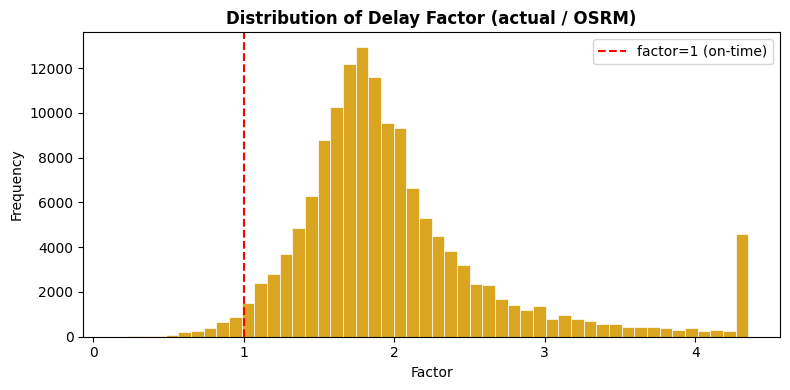

In [18]:
print("'factor' = actual_time / osrm_time")
print(df["factor"].describe().round(3))

fig, ax = plt.subplots(figsize=(8, 4))
factor_capped = df["factor"].clip(upper=df["factor"].quantile(0.97))
ax.hist(factor_capped, bins=50, color="goldenrod", edgecolor="white", linewidth=0.5)
ax.axvline(1.0, color="red", linestyle="--", linewidth=1.5, label="factor=1 (on-time)")
ax.set_title("Distribution of Delay Factor (actual / OSRM)", fontweight="bold")
ax.set_xlabel("Factor")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.savefig("eda_factor_dist.png", dpi=110, bbox_inches="tight")
plt.show()


## 8. Time-Based Patterns

In [21]:
df["trip_creation_time"] = pd.to_datetime(df["trip_creation_time"])
df["hour"]      = df["trip_creation_time"].dt.hour
df["day_of_week"] = df["trip_creation_time"].dt.dayofweek
df["month"]     = df["trip_creation_time"].dt.month


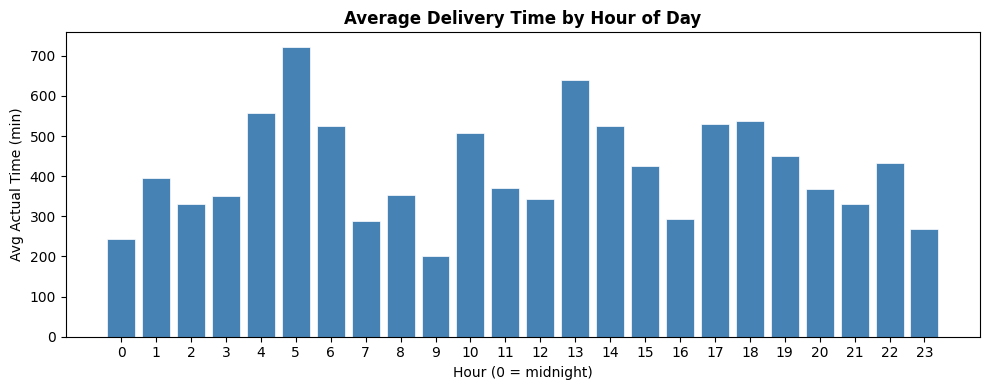

In [22]:
hourly = df.groupby('hour')["actual_time"].mean().round(1)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(hourly.index, hourly.values, color="steelblue", edgecolor="white", linewidth=0.5)
ax.set_title("Average Delivery Time by Hour of Day", fontweight="bold")
ax.set_xlabel("Hour (0 = midnight)")
ax.set_ylabel("Avg Actual Time (min)")
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.savefig("eda_hourly.png", dpi=110, bbox_inches="tight")
plt.show()


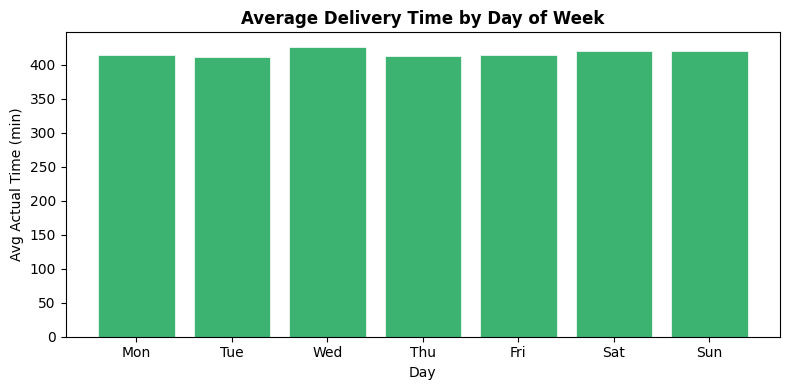

In [23]:
day_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
daily = df.groupby("day_of_week")["actual_time"].mean().round(1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(day_labels, daily.values, color="mediumseagreen", edgecolor="white", linewidth=0.5)
ax.set_title("Average Delivery Time by Day of Week", fontweight="bold")
ax.set_xlabel("Day")
ax.set_ylabel("Avg Actual Time (min)")
plt.tight_layout()
plt.savefig("eda_daily.png", dpi=110, bbox_inches="tight")
plt.show()


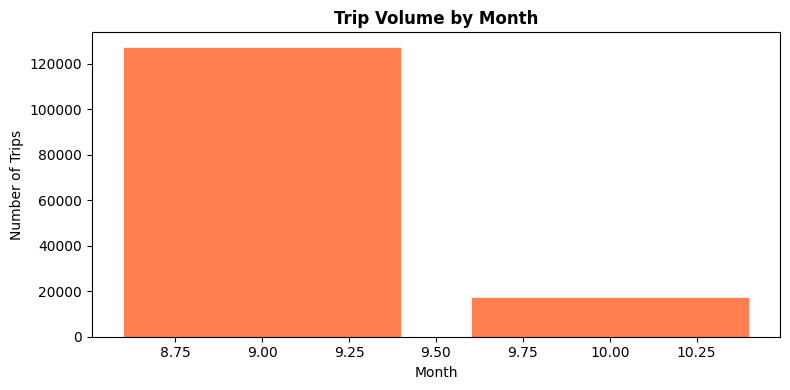

In [24]:
monthly_volume = df.groupby("month").size()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(monthly_volume.index, monthly_volume.values, color="coral", edgecolor="white", linewidth=0.5)
ax.set_title("Trip Volume by Month", fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Trips")
plt.tight_layout()
plt.savefig("eda_monthly_volume.png", dpi=110, bbox_inches="tight")
plt.show()


## 9. Correlation with `actual_time`

Correlation with actual_time:
segment_factor                    0.0176
factor                            0.0335
segment_actual_time               0.1244
segment_osrm_time                 0.1715
segment_osrm_distance             0.2423
start_scan_to_end_scan            0.7859
osrm_time                         0.9780
actual_distance_to_destination    0.9787
cutoff_factor                     0.9787
osrm_distance                     0.9794
Name: actual_time, dtype: float64


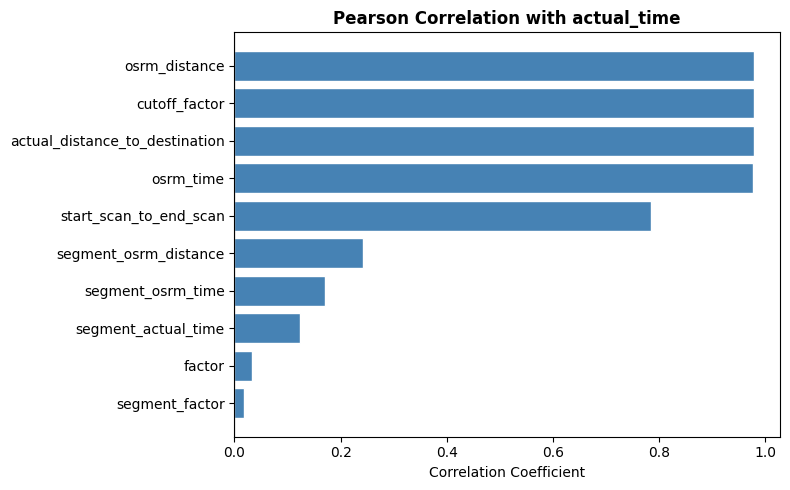

In [25]:
numeric_df = df[["actual_time", "actual_distance_to_destination", "osrm_time",
"osrm_distance", "factor", "segment_actual_time","segment_osrm_time", "segment_osrm_distance",
 "segment_factor", "cutoff_factor", "start_scan_to_end_scan"]].copy()

corr = numeric_df.corr()["actual_time"].drop("actual_time").sort_values(ascending=True)

print("Correlation with actual_time:")
print(corr.round(4))

fig, ax = plt.subplots(figsize=(8, 5))
colors_bar = ["coral" if v < 0 else "steelblue" for v in corr.values]
ax.barh(corr.index, corr.values, color=colors_bar, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Pearson Correlation with actual_time", fontweight="bold")
ax.set_xlabel("Correlation Coefficient")
plt.tight_layout()
plt.savefig("eda_correlation.png", dpi=110, bbox_inches="tight")
plt.show()


## 10. EDA Key Takeaways

| Observation | Detail |
|-------------|--------|
| **Dataset size** | 144,867 rows, 24 columns; ~72% training, ~28% test |
| **Route types** | FTL (68.8%) and Carting (31.2%) — class imbalance exists |
| **Missing values** | Only `source_name` (293) and `destination_name` (261) — negligible |
| **Target skew** | `actual_time` is right-skewed; median ~132 min, mean ~417 min |
| **Factor > 1** | Most trips take longer than OSRM estimates (median factor ~1.86) |
| **Strongest correlates** | `osrm_distance` and `actual_distance_to_destination` dominate |
| **Time pattern** | Late-night trips (0–4 h) tend to have shorter delivery times |
| **FTL vs Carting** | FTL has higher average delivery times due to longer distances |
